In [1]:
import numpy as np
import pandas as pd
import os

# ================= 1. 配置参数 =================
NUM_CHANNELS = 10      # 将 200kHz 带宽划分为 10 个子信道
WINDOW_SIZE = 10       # 历史观测窗口长度（用过去 10 个时刻预测未来）
FS = 200000            # 采样率 200kHz
CH_BW = FS / NUM_CHANNELS  # 每个信道带宽 20kHz
TOTAL_STEPS = 10000    # 总时间步数（模拟约 10-15 分钟的观测）

# ================= 2. 态势规律生成逻辑 =================

def generate_situation_logic(steps):
    """
    模拟具有物理规律的干扰信道占用演变
    模式：扫频(Sweep)、规律跳频(Hopping)、突发(Burst)
    """
    data = []
    curr_ch = 0
    
    for t in range(steps):
        occ = np.zeros(NUM_CHANNELS)
        
        # 模拟规律 A：扫频干扰 (每 5 个时间步移动一个信道)
        if t % 3000 < 1000:
            if t % 5 == 0:
                curr_ch = (curr_ch + 1) % NUM_CHANNELS
            occ[curr_ch] = 1.0
            
        # 模拟规律 B：周期跳频 (在信道 2, 5, 8 之间循环)
        elif t % 3000 < 2000:
            hop_pattern = [2, 5, 8]
            curr_ch = hop_pattern[(t // 10) % len(hop_pattern)]
            occ[curr_ch] = 1.0
            
        # 模拟规律 C：复杂组合干扰 (梳状谱 + 随机突发)
        else:
            occ[1] = 1.0  # 固定干扰
            if np.random.rand() > 0.7:
                occ[np.random.randint(4, 9)] = 1.0 # 随机突发
        
        data.append(occ)
    return np.array(data)

# ================= 3. 数据预处理：构造滑窗序列 =================

def create_dataset(raw_data, window):
    """
    将原始序列转为 Transformer 输入: [Samples, Window, Channels]
    和标签: [Samples, Channels] (预测下一时刻的占用概率)
    """
    X, y = [], []
    for i in range(len(raw_data) - window):
        # 输入：过去 window 步的 10 维信道状态
        X.append(raw_data[i : i + window])
        # 标签：当前时刻的“未来步”状态
        y.append(raw_data[i + window])
    return np.array(X), np.array(y)

# ================= 4. 主程序：生成并保存 =================

def main():
    print("🚀 开始生成干扰态势仿真数据集...")
    
    # 1. 生成原始演变序列
    raw_occ_data = generate_situation_logic(TOTAL_STEPS)
    
    # 2. 构造 Transformer 训练集
    X, y = create_dataset(raw_occ_data, WINDOW_SIZE)
    
    # 3. 划分数据集 (严格按时间轴顺序) 
    train_split = int(0.8 * len(X))
    X_train, X_test = X[:train_split], X[train_split:]
    y_train, y_test = y[:train_split], y[train_split:]
    
    print(f"✅ 数据生成完毕！")
    print(f"📊 训练集规模: {X_train.shape}, 测试集规模: {X_test.shape}")
    
    # 4. 保存为 .npy 供 Transformer 脚本调用
    save_path = "./situation_prediction_data"
    os.makedirs(save_path, exist_ok=True)
    np.save(f"{save_path}/X_train.npy", X_train)
    np.save(f"{save_path}/y_train.npy", y_train)
    np.save(f"{save_path}/X_test.npy", X_test)
    np.save(f"{save_path}/y_test.npy", y_test)
    
    print(f"💾 数据集已保存至: {save_path}")

if __name__ == "__main__":
    main()

🚀 开始生成干扰态势仿真数据集...
✅ 数据生成完毕！
📊 训练集规模: (7992, 10, 10), 测试集规模: (1998, 10, 10)
💾 数据集已保存至: ./situation_prediction_data


In [2]:
import numpy as np
import pandas as pd
import os
import re
from sklearn.model_selection import train_test_split

# ================= 1. 基础配置 =================
FS = 200000            # 200kHz 采样率
NUM_CHANNELS = 10      # 划分为 10 个子信道
WINDOW_SIZE = 10       # Transformer 观测窗口 (过去10个时刻)
PREDICT_STEP = 1       # 预测未来第 1 个时刻
SAVE_PATH = "./prediction_dataset_v2"
os.makedirs(SAVE_PATH, exist_ok=True)

# ================= 2. 模拟研究点一的感知逻辑 =================

def mbf_plenet_perception(true_fc, true_bw, jnr):
    """
    模拟 MBF-PLENet 模型的输出结果
    在 20dB 下，它能够以极高精度还原 Fc 和 BW
    """
    # 模拟感知的微小误差 (对齐你报表中的 NRMSE 0.06)
    obs_fc = true_fc + np.random.normal(0, 500) 
    obs_bw = true_bw + np.random.normal(0, 1000)
    
    # 将感知到的物理参数转化为 10 维信道占用向量 (One-hot 思想)
    occupancy = np.zeros(NUM_CHANNELS)
    ch_bw = FS / NUM_CHANNELS
    
    # 计算干扰覆盖范围
    f_start = obs_fc - obs_bw/2
    f_end = obs_fc + obs_bw/2
    
    for i in range(NUM_CHANNELS):
        # 每个信道的频率范围
        bin_start = -FS/2 + i * ch_bw
        bin_end = bin_start + ch_bw
        # 如果干扰频率重叠超过信道宽度的 30%，认为该信道被占用
        overlap = min(f_end, bin_end) - max(f_start, bin_start)
        if overlap > 0.3 * ch_bw:
            occupancy[i] = 1.0
            
    return occupancy

# ================= 3. 构造具有态势规律的干扰序列 =================

def generate_situation_stream(steps=5000, jnr=15):
    """
    模拟三种典型的卫星干扰态势模式
    """
    stream = []
    print(f"🔄 正在模拟干扰态势演变 (JNR={jnr}dB)...")
    
    for t in range(steps):
        # 模式1: 扫频干扰 (Sweep) - 规律移动
        if t < 2000:
            fc = -70e3 + (t % 140) * 1000  # 频率随时间线性漂移
            bw = 15e3
        # 模式2: 周期跳频 (Hopping) - 周期性切换
        elif t < 4000:
            hop_list = [-60e3, -20e3, 20e3, 60e3]
            fc = hop_list[(t // 10) % len(hop_list)]
            bw = 10e3
        # 模式3: 随机动态组合 (Mixed)
        else:
            fc = np.random.uniform(-80e3, 80e3)
            bw = np.random.uniform(5e3, 30e3)
            
        # 经过感知模型识别，转化为信道占用向量
        obs_occ = mbf_plenet_perception(fc, bw, jnr)
        stream.append(obs_occ)
        
    return np.array(stream)

# ================= 4. 封装为 Transformer 训练集 =================

def build_final_dataset():
    # 1. 生成原始感知流
    raw_data = generate_situation_stream(steps=6000, jnr=20)
    
    X, y = [], []
    # 使用滑动窗口构造 [Window, 10] -> [1, 10]
    for i in range(len(raw_data) - WINDOW_SIZE - PREDICT_STEP + 1):
        X.append(raw_data[i : i + WINDOW_SIZE])
        y.append(raw_data[i + WINDOW_SIZE + PREDICT_STEP - 1])
        
    X = np.array(X) # Shape: [N, 10, 10]
    y = np.array(y) # Shape: [N, 10]
    
    # 2. 划分数据集 (7:2:1)
    X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=1/3, random_state=42)
    
    # 3. 保存数据
    np.save(f"{SAVE_PATH}/X_train.npy", X_train)
    np.save(f"{SAVE_PATH}/y_train.npy", y_train)
    np.save(f"{SAVE_PATH}/X_test.npy", X_test)
    np.save(f"{SAVE_PATH}/y_test.npy", y_test)
    
    print(f"\n✅ 数据集生成完成！")
    print(f"📍 训练集: {X_train.shape}, 标签: {y_train.shape}")
    print(f"📍 测试集: {X_test.shape}")
    print(f"📁 已保存至: {SAVE_PATH}")

if __name__ == "__main__":
    build_final_dataset()

🔄 正在模拟干扰态势演变 (JNR=20dB)...

✅ 数据集生成完成！
📍 训练集: (4193, 10, 10), 标签: (4193, 10)
📍 测试集: (599, 10, 10)
📁 已保存至: ./prediction_dataset_v2


🚀 启动增强型干扰态势仿真...
🎨 科学态势热力图已保存: enhanced_situation_heatmap.png


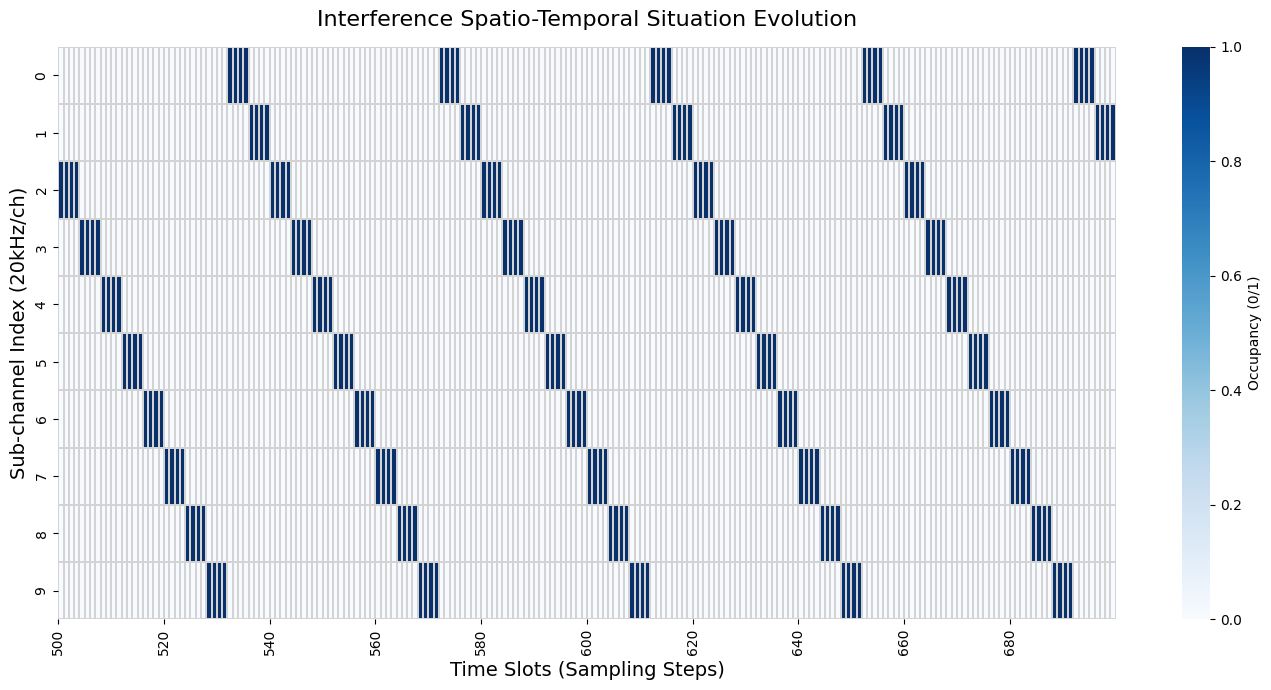


✅ 数据准备就绪：
📦 训练集: (9590, 12, 10) | 验证集: (1199, 12, 10) | 测试集: (1199, 12, 10)
💾 数据已安全写入: ./situation_data_enhanced


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

# ================= 1. 物理参数与仿真配置 =================
FS = 200000            # 带宽 200kHz
NUM_CHANNELS = 10      # 划分为 10 个子信道 (每个 20kHz)
WINDOW_SIZE = 12       # 观测窗口增加到 12 (捕捉更长的时序依赖)
TOTAL_STEPS = 12000    # 增加数据量以支撑复杂模式学习
SAVE_PATH = "./situation_data_enhanced"
os.makedirs(SAVE_PATH, exist_ok=True)

# ================= 2. 增强型态势演变逻辑 =================

def generate_enhanced_logic(steps):
    """
    模拟具有高度物理相关性的干扰演变规律
    包含：线性扫频、周期跳频、宽带突发、以及混合模式
    """
    data = []
    # 状态变量，用于保证扫频的连续性
    sweep_ch = np.random.randint(0, NUM_CHANNELS)
    
    for t in range(steps):
        occ = np.zeros(NUM_CHANNELS)
        
        # 模式 1: 复杂扫频干扰 (占比 30%) - 模拟扫频速率变化
        if t % 4000 < 1200:
            if t % 4 == 0:  # 每4个步长移动一次，模拟连续性
                sweep_ch = (sweep_ch + 1) % NUM_CHANNELS
            occ[sweep_ch] = 1.0
            
        # 模式 2: 动态跳频 (占比 30%) - 模拟固定序列跳频
        elif t % 4000 < 2400:
            hop_pattern = [1, 4, 2, 7, 3, 9] # 非线性跳频序列
            curr_ch = hop_pattern[(t // 8) % len(hop_pattern)]
            occ[curr_ch] = 1.0
            
        # 模式 3: 混合模式 (占比 40%) - 核心提升点！同时存在固定干扰和随机突发
        else:
            occ[5] = 1.0  # 信道 5 存在窄带固定干扰
            if t % 20 < 5: # 周期性突发脉冲
                occ[2] = 1.0
            if np.random.rand() > 0.85: # 随机干扰，模拟环境噪声
                occ[np.random.randint(0, 10)] = 1.0
        
        data.append(occ)
    return np.array(data)

# ================= 3. 数据构造与划分 =================

def prepare_tensors(raw_data, window):
    X, y = [], []
    for i in range(len(raw_data) - window):
        X.append(raw_data[i : i + window])
        y.append(raw_data[i + window])
    return np.array(X), np.array(y)

# ================= 4. 高质量可视化函数 =================

def visualize_situation_scientific(raw_data, sample_range=(500, 700)):
    """
    生成符合论文标准的态势可视化图
    raw_data: 原始 [Steps, Channels] 矩阵
    """
    plot_data = raw_data[sample_range[0]:sample_range[1]].T
    
    plt.figure(figsize=(14, 7))
    
    # 绘制热力图：展示干扰的时频演变
    ax = sns.heatmap(plot_data, cmap="Blues", cbar_kws={'label': 'Occupancy (0/1)'},
                    linewidths=0.01, linecolor='lightgrey')
    
    plt.title("Interference Spatio-Temporal Situation Evolution", fontsize=16, pad=15)
    plt.xlabel("Time Slots (Sampling Steps)", fontsize=14)
    plt.ylabel("Sub-channel Index (20kHz/ch)", fontsize=14)
    
    # 设置刻度
    plt.xticks(np.arange(0, sample_range[1]-sample_range[0], 20), 
               np.arange(sample_range[0], sample_range[1], 20))
    plt.yticks(np.arange(0.5, 10.5, 1), np.arange(0, 10, 1))
    
    plt.tight_layout()
    plt.savefig("enhanced_situation_heatmap.png", dpi=600)
    print("🎨 科学态势热力图已保存: enhanced_situation_heatmap.png")
    plt.show()

# ================= 5. 主程序执行 =================

def main():
    print("🚀 启动增强型干扰态势仿真...")
    
    # 1. 生成原始序列
    raw_occ_data = generate_enhanced_logic(TOTAL_STEPS)
    
    # 2. 可视化检查规律性
    visualize_situation_scientific(raw_occ_data)
    
    # 3. 构造 Transformer 训练张量
    X, y = prepare_tensors(raw_occ_data, WINDOW_SIZE)
    
    # 4. 划分数据集 (严格按时间轴)
    # 前 80% 训练，10% 验证，最后 10% 留作期末测试
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, shuffle=False)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)
    
    print(f"\n✅ 数据准备就绪：")
    print(f"📦 训练集: {X_train.shape} | 验证集: {X_val.shape} | 测试集: {X_test.shape}")
    
    # 5. 保存
    np.save(f"{SAVE_PATH}/X_train.npy", X_train)
    np.save(f"{SAVE_PATH}/y_train.npy", y_train)
    np.save(f"{SAVE_PATH}/X_val.npy", X_val)
    np.save(f"{SAVE_PATH}/X_test.npy", X_test)
    np.save(f"{SAVE_PATH}/y_test.npy", y_test)
    print(f"💾 数据已安全写入: {SAVE_PATH}")

if __name__ == "__main__":
    main()

In [4]:
import numpy as np
import os

# ================= 1. 物理参数与同步配置 =================
FS_USRP = 1e6              
CH_BW = 20e3               
NUM_CHANNELS = 10          
TOTAL_STEPS = 4000         # 增加时长以覆盖更多模式
STEP_DURATION = 0.05       
SAMPLES_PER_STEP = int(FS_USRP * STEP_DURATION) 

# 巴克码同步头 (13位)
BARKER_13 = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])
PREAMBLE_SEQ = np.repeat(BARKER_13, 100).astype(np.complex64)
PREAMBLE_LEN = len(PREAMBLE_SEQ)

JNR_DB = 15 
SIGNAL_AMP = 10**(JNR_DB / 20.0)

# ================= 2. 四种经典干扰演变逻辑 =================

def get_comprehensive_logic(steps):
    data = []
    sweep_ch = 0
    for t in range(steps):
        occ = np.zeros(NUM_CHANNELS)
        
        # 模式 1: 线性扫频 (Linear Sweep) - 连续性演变
        if t % 4000 < 1000:
            if t % 4 == 0: sweep_ch = (sweep_ch + 1) % NUM_CHANNELS
            occ[sweep_ch] = 1.0
            
        # 模式 2: 快速跳频 (Fast Hopping) - 离散性演变
        elif t % 4000 < 2000:
            hop_pattern = [1, 5, 2, 8, 3, 9, 0, 4, 7, 6]
            curr_ch = hop_pattern[(t // 5) % len(hop_pattern)]
            occ[curr_ch] = 1.0
            
        # 模式 3: 梳状干扰 (Comb/Multi-tone) - 空间分布演变
        elif t % 4000 < 3000:
            comb_channels = [1, 3, 5, 7, 9] if (t // 20) % 2 == 0 else [0, 2, 4, 6, 8]
            for ch in comb_channels: occ[ch] = 1.0
            
        # 模式 4: 周期脉冲 + 随机突发 (Pulse & Burst) - 时域突变演变
        else:
            if t % 10 < 4: # 固定脉冲
                occ[4] = 1.0; occ[5] = 1.0
            if np.random.rand() > 0.9: # 随机突发
                occ[np.random.randint(0, 10)] = 1.0
                
        data.append(occ)
    return np.array(data)

# ================= 3. 信号合成与数据集保存 =================

def generate_final_dataset():
    occ_labels = get_comprehensive_logic(TOTAL_STEPS)
    # 保存真值用于验证和 Transformer 训练
    np.save("tx_ground_truth_labels.npy", occ_labels)
    
    print(f"📡 正在生成包含 4 种干扰样式的带同步头 IQ 信号...")
    
    with open("interference_signal.dat", "wb") as f:
        # 写入同步头 (重复 5 次增强鲁棒性)
        for _ in range(5): f.write(PREAMBLE_SEQ.tobytes())
        
        for t in range(TOTAL_STEPS):
            step_iq = np.zeros(SAMPLES_PER_STEP, dtype=np.complex64)
            t_axis = np.arange(SAMPLES_PER_STEP) / FS_USRP
            
            for ch in range(NUM_CHANNELS):
                if occ_labels[t][ch] == 1.0:
                    f_offset = (ch - (NUM_CHANNELS - 1) / 2) * CH_BW
                    noise = (np.random.randn(SAMPLES_PER_STEP) + 1j*np.random.randn(SAMPLES_PER_STEP))
                    step_iq += noise.astype(np.complex64) * np.exp(1j * 2 * np.pi * f_offset * t_axis)
            
            # 叠加噪声
            noise_floor = (np.random.randn(SAMPLES_PER_STEP) + 1j*np.random.randn(SAMPLES_PER_STEP)) / np.sqrt(2)
            final_signal = (step_iq * SIGNAL_AMP) + noise_floor
            
            # 归一化写入
            max_v = np.max(np.abs(final_signal))
            if max_v > 0: final_signal /= max_v
            f.write(final_signal.astype(np.complex64).tobytes())

    print(f"✅ 完成！干扰样式已扩展至 4 种，包含同步头。")

def preprocess_for_transformer(label_path="tx_ground_truth_labels.npy", window=12):
    data = np.load(label_path)
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
        y.append(data[i + window])
    
    # 划分并保存
    X, y = np.array(X), np.array(y)
    split = int(0.8 * len(X))
    np.save("situation_data_v1/X_train_v2.npy", X[:split])
    np.save("situation_data_v1/y_train_v2.npy", y[:split])
    np.save("situation_data_v1/X_test_v2.npy", X[split:])
    np.save("situation_data_v1/y_test_v2.npy", y[split:])
    print("✅ 预处理完成，可直接用于模型训练验证。")

if __name__ == "__main__":
    generate_final_dataset()
    preprocess_for_transformer()

📡 正在生成包含 4 种干扰样式的带同步头 IQ 信号...
✅ 完成！干扰样式已扩展至 4 种，包含同步头。
✅ 预处理完成，可直接用于模型训练验证。


✅ 优化后的态势图已保存：refined_situation_spectrogram.png


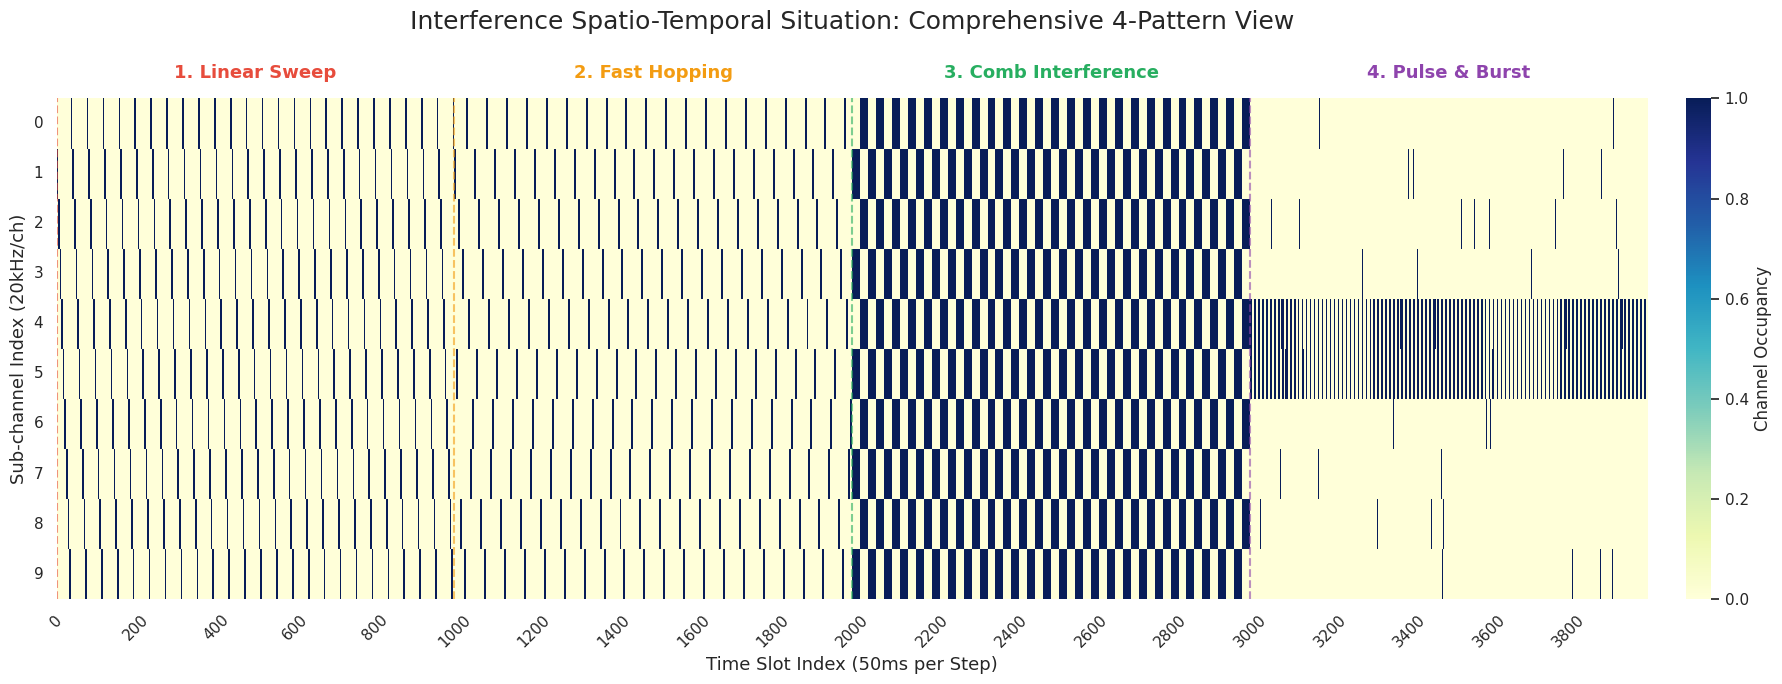

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_refined_spectrogram(label_path="tx_ground_truth_labels.npy"):
    """
    通过调整布局和采样密度，解决图像拥挤和标题重叠问题
    """
    if not os.path.exists(label_path):
        print(f"❌ 错误：未找到文件 {label_path}")
        return
    
    # 1. 加载数据 [Steps, Channels]
    data = np.load(label_path)
    
    # 2. 动态调整画布比例 (增加宽度以适应 4000 个点)
    # 这里的 figsize=(20, 6) 能显著缓解拥挤感
    plt.figure(figsize=(20, 7))
    
    # 3. 绘制热力图
    # cmap 建议使用 'magma' 或 'YlGnBu'，在黑白打印时也有很好的区分度
    ax = sns.heatmap(data.T, cmap="YlGnBu", cbar_kws={'label': 'Channel Occupancy', 'pad': 0.02},
                    xticklabels=200, yticklabels=1) # 每200步显示一个刻度

    # 4. 优化小标题位置：将标题稍微上移，防止与坐标轴重叠
    patterns = [
        (0, 1000, "1. Linear Sweep", "#E74C3C"),   # 线性扫频
        (1000, 2000, "2. Fast Hopping", "#F39C12"), # 快速跳频
        (2000, 3000, "3. Comb Interference", "#27AE60"), # 梳状干扰
        (3000, 4000, "4. Pulse & Burst", "#8E44AD")  # 脉冲与突发
    ]
    
    for start, end, name, color in patterns:
        # 绘制边界虚线
        ax.axvline(x=start, color=color, linestyle='--', linewidth=1.5, alpha=0.6)
        # 调整文本位置 (y=-1.2 代表在图表上方更远一点)
        ax.text((start + end)/2, -0.5, name, color=color, 
                ha='center', va='center', fontsize=13, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 5. 图表修饰与美化
    ax.set_title("Interference Spatio-Temporal Situation: Comprehensive 4-Pattern View", 
                 fontsize=18, pad=50) # 增加 pad 防止主标题压住小标题
    ax.set_xlabel("Time Slot Index (50ms per Step)", fontsize=13)
    ax.set_ylabel("Sub-channel Index (20kHz/ch)", fontsize=13)
    
    # 旋转刻度标签，防止重叠
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    # 6. 保存高质量矢量图 (适合放入 Word 论文)
    plt.tight_layout()
    plt.savefig("refined_situation_spectrogram.png", dpi=600, bbox_inches='tight')
    print("✅ 优化后的态势图已保存：refined_situation_spectrogram.png")
    plt.show()

if __name__ == "__main__":
    plot_refined_spectrogram()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']


✅ 全维度数据集分析图已保存: comprehensive_dataset_analysis.png


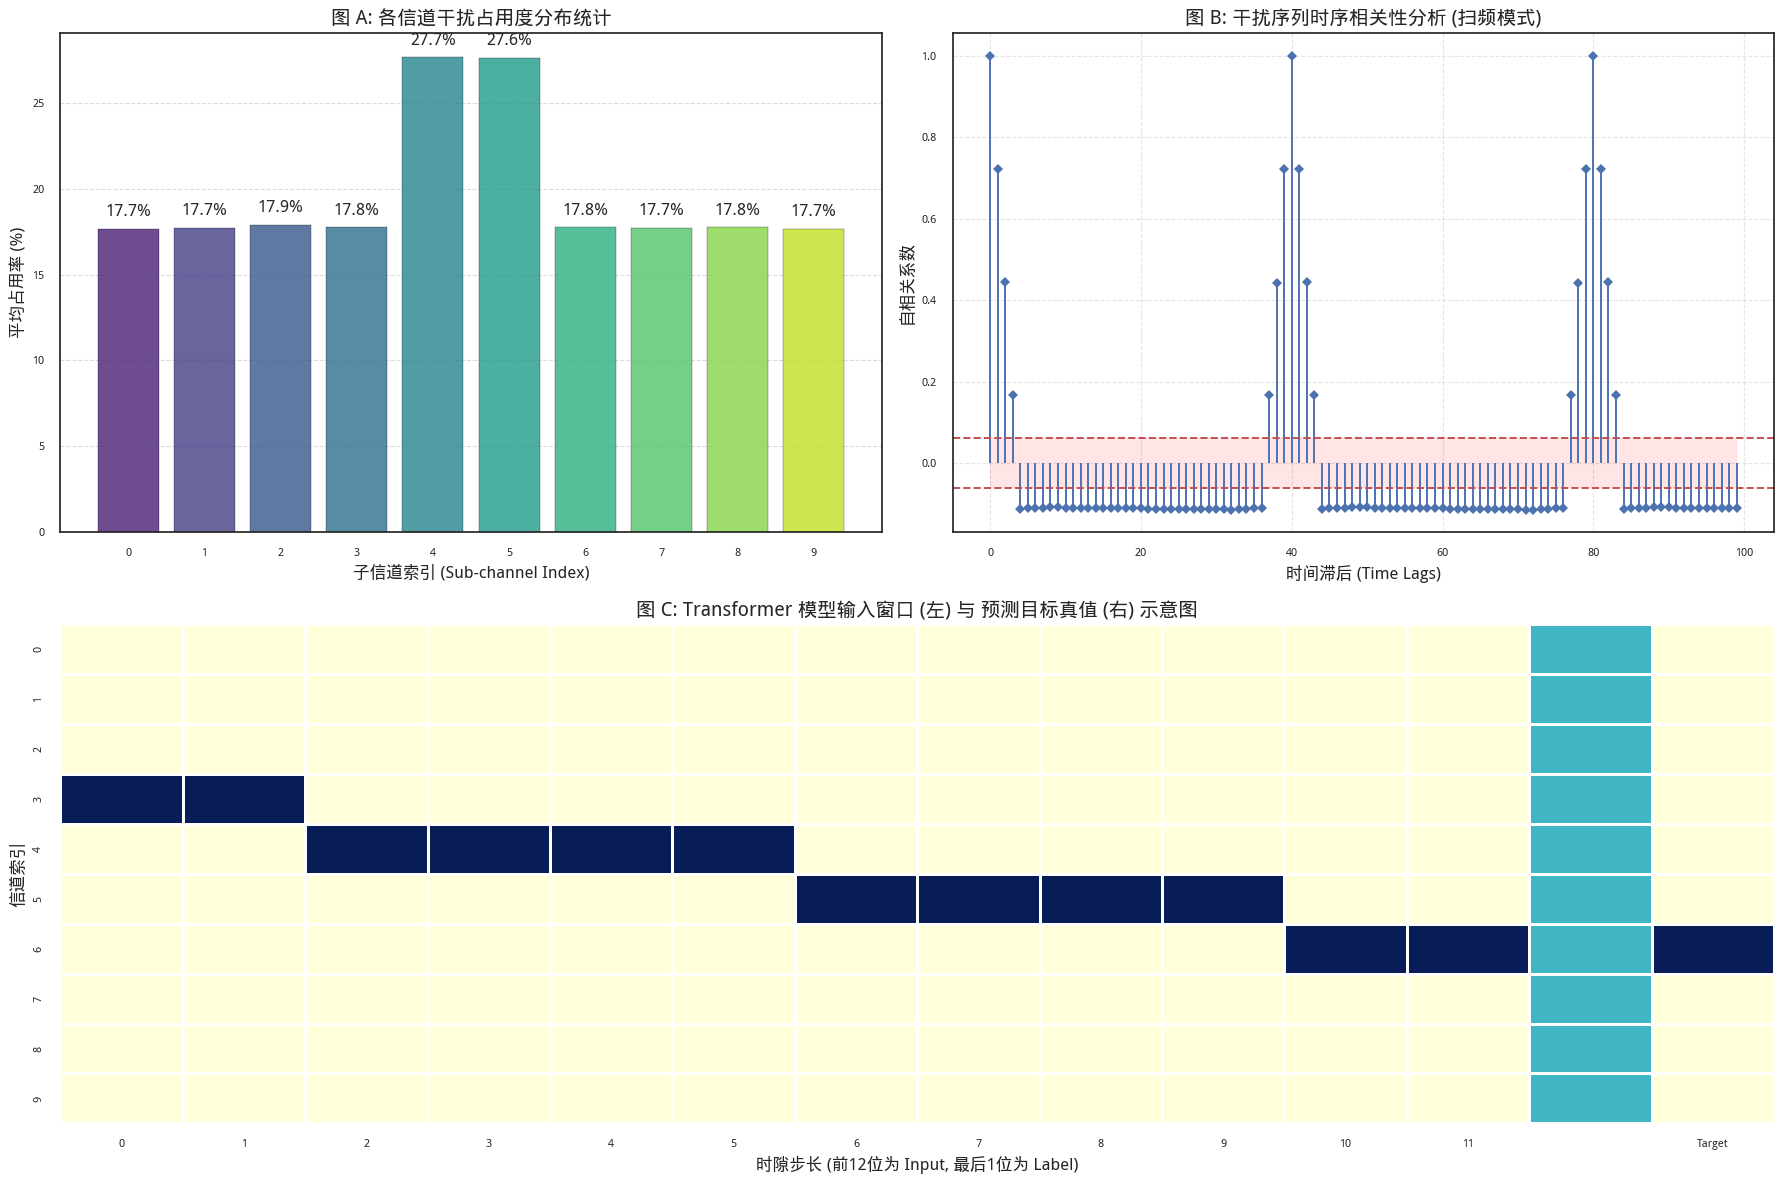

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm
import pandas as pd

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ================= 1. 环境配置 =================
# 设置学术绘图风格
plt.style.use('seaborn-v0_8-paper') 
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正常显示中文 (如环境不支持可改为 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

def manual_autocorr(x, lags):
    """手动计算自相关系数，替代 statsmodels"""
    n = len(x)
    mu = np.mean(x)
    res = []
    for l in range(lags):
        if l == 0:
            res.append(1.0)
        else:
            # 计算滞后项的相关性
            c = np.correlate(x[:n-l] - mu, x[l:] - mu)[0]
            var = np.var(x) * (n - l)
            res.append(c / var if var != 0 else 0)
    return np.array(res)

def plot_comprehensive_analysis(label_path="tx_ground_truth_labels.npy"):
    if not os.path.exists(label_path):
        print(f"❌ 错误：未找到数据文件 {label_path}，请确保已运行数据集生成脚本。")
        return
    
    # 2. 加载数据 [Steps, Channels]
    data = np.load(label_path)
    num_steps, num_channels = data.shape

    # 创建一个包含三个子图的大图
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2)

    # --- 图 A: 干扰占用度统计 (Occupancy Stats) ---
    ax1 = fig.add_subplot(gs[0, 0])
    avg_occupancy = np.mean(data, axis=0) * 100
    colors = sns.color_palette("viridis", num_channels)
    bars = ax1.bar(range(num_channels), avg_occupancy, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_xlabel('子信道索引 (Sub-channel Index)', fontsize=12)
    ax1.set_ylabel('平均占用率 (%)', fontsize=12)
    ax1.set_title('图 A: 各信道干扰占用度分布统计', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(num_channels))
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', va='bottom')

    # --- 图 B: 自相关性分析曲线 (Autocorrelation) ---
    # 证明干扰随时间的可预测性
    ax2 = fig.add_subplot(gs[0, 1])
    lags = 100
    # 绘制扫频模式下的自相关 (选取前1000步)
    acf_values = manual_autocorr(data[:1000, 2], lags) 
    ax2.stem(range(lags), acf_values, basefmt=" ", markerfmt="D")
    # 绘制 95% 置信区间 (模拟)
    conf = 1.96 / np.sqrt(1000)
    ax2.axhline(y=conf, color='r', linestyle='--', label='95% 置信区间')
    ax2.axhline(y=-conf, color='r', linestyle='--')
    ax2.fill_between(range(lags), -conf, conf, color='red', alpha=0.1)
    ax2.set_xlabel('时间滞后 (Time Lags)', fontsize=12)
    ax2.set_ylabel('自相关系数', fontsize=12)
    ax2.set_title('图 B: 干扰序列时序相关性分析 (扫频模式)', fontsize=14, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # --- 图 C: 滑窗样本切片 (Transformer Input/Output) ---
    # 直观展示预测任务的逻辑
    ax3 = fig.add_subplot(gs[1, :])
    window_size = 12
    sample_idx = 450 # 扫频干扰的典型片段
    input_slice = data[sample_idx : sample_idx + window_size].T
    target_slice = data[sample_idx + window_size].reshape(-1, 1)
    
    # 拼接一下方便显示
    combined = np.hstack([input_slice, np.ones((num_channels, 1))*0.5, target_slice]) 
    sns.heatmap(combined, cmap="YlGnBu", cbar=False, ax=ax3, linewidths=1, linecolor='white')
    
    # 添加标注说明
    ax3.set_title('图 C: Transformer 模型输入窗口 (左) 与 预测目标真值 (右) 示意图', fontsize=14, fontweight='bold')
    ax3.set_xlabel('时隙步长 (前12位为 Input, 最后1位为 Label)', fontsize=12)
    ax3.set_ylabel('信道索引', fontsize=12)
    ax3.set_xticks(np.arange(window_size + 2) + 0.5)
    ax3.set_xticklabels(list(range(window_size)) + [" "] + ["Target"])

    plt.tight_layout()
    plt.savefig("comprehensive_dataset_analysis.png", dpi=600, bbox_inches='tight')
    print("✅ 全维度数据集分析图已保存: comprehensive_dataset_analysis.png")
    plt.show()

if __name__ == "__main__":
    plot_comprehensive_analysis()